# Data Quality Check - agent_data1.json

Notebook này kiểm tra dữ liệu gốc trước augmentation: `data/agent_data1.json`.

Mục tiêu cho slide:
- Kiểm tra cấu trúc mẫu dữ liệu.
- Kiểm tra `tool_used` có khớp với `assistant.tool_calls` không.
- Kiểm tra tool name thuộc tập tool hợp lệ.
- Kiểm tra argument bắt buộc, kiểu dữ liệu, khoảng giá trị và định dạng ngày.

In [13]:
import json
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd

DATA_PATH = Path("data/agent_data1.json")

with DATA_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded {len(data):,} records from {DATA_PATH}")
data[0]

Loaded 1,910 records from data\agent_data1.json


{'id': 'sample_001',
 'description': 'Kiểm tra tồn kho của một sản phẩm',
 'tool_used': ['check_inventory'],
 'messages': [{'role': 'user',
   'content': 'Bạn kiểm tra giúp tôi xem mã sản phẩm SP-8845 trong kho còn hàng không nhé.'},
  {'role': 'assistant',
   'content': None,
   'tool_calls': [{'name': 'check_inventory',
     'arguments': {'product_id': 'SP-8845'}}]}]}

In [14]:
KNOWN_TOOLS = {
    "check_inventory": {"required": {"product_id": str}},
    "revenue_analysis": {"required": {"start_date": str, "end_date": str}},
    "get_order": {"required": {"order_id": str}},
    "create_order": {"required": {"product_id": str, "quantity": int, "address": str}},
    "update_order": {"required": {"order_id": str}},
    "delete_order": {"required": {"order_id": str}},
}

OPTIONAL_TYPES = {
    "update_order": {"quantity": int, "address": str},
}

def extract_tool_calls(record):
    calls = []
    for msg in record.get("messages", []):
        if msg.get("role") == "assistant" and msg.get("tool_calls"):
            calls.extend(msg["tool_calls"])
    return calls

def parse_date(value):
    try:
        return datetime.strptime(value, "%Y-%m-%d").date()
    except Exception:
        return None

def add_error(errors, category, row_no, record_id, detail):
    errors[category].append({
        "row": row_no,
        "id": record_id,
        "detail": detail,
    })

In [15]:
errors = defaultdict(list)
tool_counts = Counter()
role_patterns = Counter()
arg_key_counts = Counter()

id_counts = Counter(record.get("id") for record in data)
duplicate_ids = sorted([record_id for record_id, count in id_counts.items() if count > 1])

for row_no, record in enumerate(data, start=1):
    record_id = record.get("id", f"row_{row_no}")

    for field in ["id", "description", "tool_used", "messages"]:
        if field not in record or record[field] in (None, ""):
            add_error(errors, "top_level_schema", row_no, record_id, f"Missing/empty field: {field}")

    if not isinstance(record.get("tool_used"), list) or not record.get("tool_used"):
        add_error(errors, "tool_used_schema", row_no, record_id, "tool_used is missing/empty/not a list")

    if not isinstance(record.get("messages"), list) or not record.get("messages"):
        add_error(errors, "message_schema", row_no, record_id, "messages is missing/empty/not a list")
        continue

    roles = tuple(message.get("role") for message in record["messages"])
    role_patterns[roles] += 1

    user_messages = [message for message in record["messages"] if message.get("role") == "user"]
    if len(user_messages) != 1 or not str(user_messages[0].get("content", "")).strip():
        add_error(errors, "user_message", row_no, record_id, f"Invalid user message count/content: {len(user_messages)}")

    tool_calls = extract_tool_calls(record)
    if not tool_calls:
        add_error(errors, "tool_call_presence", row_no, record_id, "No assistant.tool_calls found")
        continue

    call_names = [tool_call.get("name") for tool_call in tool_calls]
    used_names = list(record.get("tool_used", []))
    if Counter(call_names) != Counter(used_names):
        add_error(errors, "tool_consistency", row_no, record_id, f"tool_calls={call_names}, tool_used={used_names}")

    for tool_call in tool_calls:
        name = tool_call.get("name")
        args = tool_call.get("arguments")
        tool_counts[name] += 1

        if name not in KNOWN_TOOLS:
            add_error(errors, "known_tool", row_no, record_id, f"Unknown tool: {name}")
            continue

        if not isinstance(args, dict):
            add_error(errors, "argument_schema", row_no, record_id, f"{name}.arguments is not a dict")
            continue

        for key in args:
            arg_key_counts[f"{name}.{key}"] += 1

        for key, expected_type in KNOWN_TOOLS[name]["required"].items():
            if key not in args or args[key] in (None, ""):
                add_error(errors, "required_argument", row_no, record_id, f"{name}.{key} is missing/empty")
                continue

            if expected_type is int:
                if not isinstance(args[key], int) or isinstance(args[key], bool) or args[key] <= 0:
                    add_error(errors, "argument_type_or_range", row_no, record_id, f"{name}.{key} must be a positive int, got {args[key]!r}")
            elif expected_type is str:
                if not isinstance(args[key], str) or not args[key].strip():
                    add_error(errors, "argument_type_or_range", row_no, record_id, f"{name}.{key} must be a non-empty string")

        for key, expected_type in OPTIONAL_TYPES.get(name, {}).items():
            if key not in args or args[key] in (None, ""):
                continue
            if expected_type is int and (not isinstance(args[key], int) or isinstance(args[key], bool) or args[key] <= 0):
                add_error(errors, "argument_type_or_range", row_no, record_id, f"{name}.{key} must be a positive int, got {args[key]!r}")
            elif expected_type is str and (not isinstance(args[key], str) or not args[key].strip()):
                add_error(errors, "argument_type_or_range", row_no, record_id, f"{name}.{key} must be a non-empty string")

        if name == "revenue_analysis":
            start_date = parse_date(args.get("start_date", ""))
            end_date = parse_date(args.get("end_date", ""))
            if not start_date or not end_date:
                add_error(errors, "date_format", row_no, record_id, f"Invalid date format: {args}")
            elif start_date > end_date:
                add_error(errors, "date_range", row_no, record_id, f"start_date > end_date: {args}")

In [16]:
criteria = {
    "JSON parse & top-level schema": ["top_level_schema", "tool_used_schema", "message_schema"],
    "User message present": ["user_message"],
    "Tool call present": ["tool_call_presence"],
    "tool_used matches assistant.tool_calls": ["tool_consistency"],
    "Tool name in allowed set": ["known_tool"],
    "Required arguments complete": ["argument_schema", "required_argument"],
    "Argument type/range valid": ["argument_type_or_range"],
    "Date format/range valid": ["date_format", "date_range"],
}

quality_rows = []
for criterion, categories in criteria.items():
    failing_rows = {error["row"] for category in categories for error in errors[category]}
    passed = len(data) - len(failing_rows)
    quality_rows.append({
        "criterion": criterion,
        "passed": passed,
        "total": len(data),
        "pass_rate": f"{passed / len(data) * 100:.2f}%",
        "error_count": sum(len(errors[category]) for category in categories),
    })

quality_df = pd.DataFrame(quality_rows)
tool_df = pd.DataFrame(
    [{"tool": tool, "samples": count, "ratio": f"{count / len(data) * 100:.2f}%"} for tool, count in sorted(tool_counts.items())]
)
error_df = pd.DataFrame(
    [{"category": category, "error_count": len(items)} for category, items in sorted(errors.items())]
)

display(quality_df)
display(tool_df)
display(error_df)

,criterion,passed,total,pass_rate,error_count
0,JSON parse & top-level schema,1910,1910,100.00%,0
1,User message present,1910,1910,100.00%,0
2,Tool call present,1910,1910,100.00%,0
3,tool_used matches assistant.tool_calls,1910,1910,100.00%,0
4,Tool name in allowed set,1910,1910,100.00%,0
5,Required arguments complete,1910,1910,100.00%,0
6,Argument type/range valid,1910,1910,100.00%,0
7,Date format/range valid,1910,1910,100.00%,0


,tool,samples,ratio
0,check_inventory,361,18.90%
1,create_order,353,18.48%
2,delete_order,268,14.03%
3,get_order,312,16.34%
4,revenue_analysis,346,18.12%
5,update_order,270,14.14%


,category,error_count
0,argument_schema,0
1,argument_type_or_range,0
2,date_format,0
3,date_range,0
4,known_tool,0
5,message_schema,0
6,required_argument,0
7,tool_call_presence,0
8,tool_consistency,0
9,tool_used_schema,0


In [17]:
summary = {
    "dataset": str(DATA_PATH),
    "total_records": len(data),
    "unique_ids": len(id_counts),
    "duplicate_id_groups": len(duplicate_ids),
    "duplicate_ids": duplicate_ids,
    "role_patterns": {" -> ".join(pattern): count for pattern, count in role_patterns.items()},
    "tool_distribution": dict(sorted(tool_counts.items())),
}

print("SLIDE-READY SUMMARY")
print(f"- Total samples: {summary['total_records']:,}")
print(f"- Unique IDs: {summary['unique_ids']:,}/{summary['total_records']:,}")
print(f"- Duplicate ID groups: {summary['duplicate_id_groups']}")
print(f"- Message structure: {summary['role_patterns']}")
print("- Tool distribution:")
for tool, count in summary["tool_distribution"].items():
    print(f"  + {tool}: {count:,} ({count / len(data) * 100:.2f}%)")

print("\nCore validation:")
for row in quality_rows:
    print(f"- {row['criterion']}: {row['passed']:,}/{row['total']:,} ({row['pass_rate']}), errors={row['error_count']}")

SLIDE-READY SUMMARY
- Total samples: 1,910
- Unique IDs: 1,903/1,910
- Duplicate ID groups: 7
- Message structure: {'user -> assistant': 1910}
- Tool distribution:
  + check_inventory: 361 (18.90%)
  + create_order: 353 (18.48%)
  + delete_order: 268 (14.03%)
  + get_order: 312 (16.34%)
  + revenue_analysis: 346 (18.12%)
  + update_order: 270 (14.14%)

Core validation:
- JSON parse & top-level schema: 1,910/1,910 (100.00%), errors=0
- User message present: 1,910/1,910 (100.00%), errors=0
- Tool call present: 1,910/1,910 (100.00%), errors=0
- tool_used matches assistant.tool_calls: 1,910/1,910 (100.00%), errors=0
- Tool name in allowed set: 1,910/1,910 (100.00%), errors=0
- Required arguments complete: 1,910/1,910 (100.00%), errors=0
- Argument type/range valid: 1,910/1,910 (100.00%), errors=0
- Date format/range valid: 1,910/1,910 (100.00%), errors=0


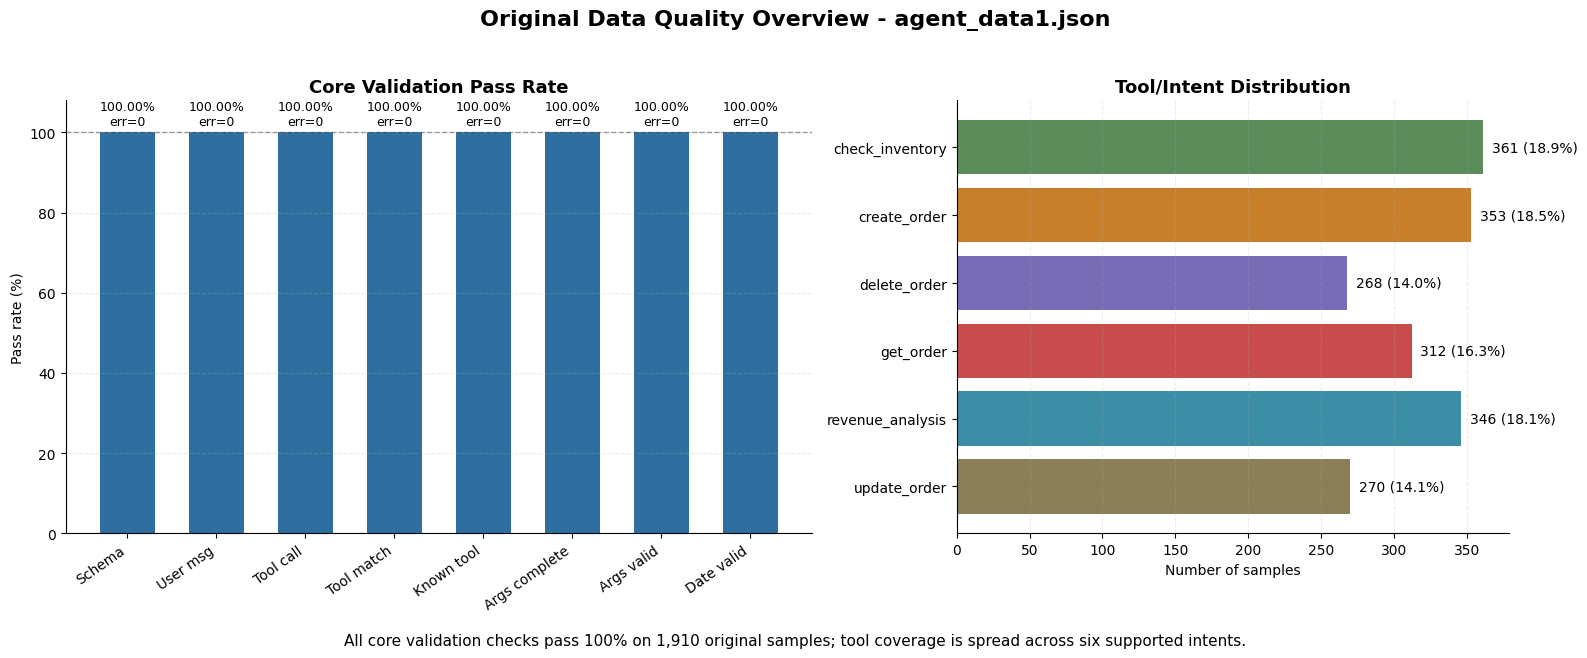

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plot_quality_df = quality_df.copy()
plot_quality_df["pass_rate_numeric"] = plot_quality_df["passed"] / plot_quality_df["total"] * 100
plot_tool_df = tool_df.copy()
plot_tool_df["ratio_numeric"] = plot_tool_df["samples"] / len(data) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.35, 1]})
fig.suptitle("Original Data Quality Overview - agent_data1.json", fontsize=16, fontweight="bold", y=1.03)

# Chart 1: validation pass rates
criteria_labels = [
    "Schema",
    "User msg",
    "Tool call",
    "Tool match",
    "Known tool",
    "Args complete",
    "Args valid",
    "Date valid",
]
x = np.arange(len(plot_quality_df))
bars = axes[0].bar(x, plot_quality_df["pass_rate_numeric"], color="#2f6f9f", width=0.62)
axes[0].set_title("Core Validation Pass Rate", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Pass rate (%)")
axes[0].set_ylim(0, 108)
axes[0].set_xticks(x)
axes[0].set_xticklabels(criteria_labels, rotation=35, ha="right")
axes[0].axhline(100, color="#444444", linewidth=1, linestyle="--", alpha=0.5)
axes[0].grid(axis="y", linestyle="--", alpha=0.25)
for bar, row in zip(bars, quality_rows):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{row['pass_rate']}\nerr={row['error_count']}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Chart 2: tool distribution
tool_colors = ["#5b8c5a", "#c87f2a", "#7a6bb7", "#c94c4c", "#3b8ea5", "#8a7f57"]
bars2 = axes[1].barh(plot_tool_df["tool"], plot_tool_df["samples"], color=tool_colors)
axes[1].set_title("Tool/Intent Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of samples")
axes[1].invert_yaxis()
axes[1].grid(axis="x", linestyle="--", alpha=0.25)
for bar, (_, row) in zip(bars2, plot_tool_df.iterrows()):
    axes[1].text(
        bar.get_width() + 6,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['samples'])} ({row['ratio_numeric']:.1f}%)",
        va="center",
        fontsize=10,
    )

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    -0.03,
    "All core validation checks pass 100% on 1,910 original samples; tool coverage is spread across six supported intents.",
    ha="center",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("data_quality_overview_agent_data1.png", dpi=200, bbox_inches="tight")
plt.show()

## Suggested Slide Content

**Data correctness validation on original dataset (`agent_data1.json`)**

- Dataset size: 1,910 original samples before augmentation.
- Message format is consistent: each sample contains one user message and one assistant tool-call message.
- Tool labels are consistent: `tool_used` matches `assistant.tool_calls` for 1,910/1,910 samples (100%).
- Tool schema is valid: all tool names belong to the predefined tool set (100%).
- Argument schema is valid: all required arguments are present and have valid types/formats (100%).
- Date arguments are normalized to `YYYY-MM-DD` and checked for valid ranges (100%).
- Overview chart: `data_quality_overview_agent_data1.png` shows 100% pass rate across core checks and a balanced distribution across 6 tools/intents.

Note: duplicate IDs are reported separately because IDs are metadata and are not used as model labels.

Slide caption suggestion: **Original data validation confirms that all 1,910 samples satisfy the required schema, tool-label consistency, argument completeness, and valid date/argument constraints before augmentation.**